# 03 - Evaluasi ROUGE & Perbandingan Waktu Proses (MP4 vs MP3 vs WAV)

Mengevaluasi performa model IndoT5 dan membandingkan waktu transkripsi Whisper antar format file.

## 1. Import

In [8]:
import pandas as pd
import evaluate
import time
from pathlib import Path
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
import torch
import matplotlib.pyplot as plt

import os
# Pastikan FFmpeg ada di PATH untuk kernel notebook
ffmpeg_dir = r"C:\Users\User\AppData\Local\Microsoft\WinGet\Packages"
for root, dirs, files in os.walk(ffmpeg_dir):
    if "ffmpeg.exe" in files:
        os.environ["PATH"] = root + ";" + os.environ["PATH"]
        print(f"✅ FFmpeg ditemukan: {root}")
        break


✅ FFmpeg ditemukan: C:\Users\User\AppData\Local\Microsoft\WinGet\Packages\Gyan.FFmpeg_Microsoft.Winget.Source_8wekyb3d8bbwe\ffmpeg-8.0.1-full_build\bin


## 2. Load Model Fine-tuned

In [9]:
MODEL_DIR = Path('../models/indot5_finetuned')
print(f"Memuat tokenizer dan model dari: {MODEL_DIR}...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR)
model     = AutoModelForSeq2SeqLM.from_pretrained(MODEL_DIR)

device    = 'cuda' if torch.cuda.is_available() else 'cpu'
model     = model.to(device).eval()
print(f"Model berhasil dimuat di device: {device}")

df_test = pd.read_csv('../dataset/03_paired/test.csv')
df_test.head()

Memuat tokenizer dan model dari: ..\models\indot5_finetuned...


Loading weights: 100%|██████████| 284/284 [00:00<00:00, 571.93it/s, Materializing param=shared.weight]                                                       
The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Model berhasil dimuat di device: cpu


,dokumen_asal,input_whisper_segment,target_summary_manual
0,Paripurna_Ke_3_Persidangan_I_2025_2026,Hei laporan Aruskas Cumlah Aruskas bersih dari...,Laporan Keuangan Pemerintah Pusat Tahun Anggar...
1,Paripurna_Ke_20_Persidangan_V_2023_2024,Berbagai reformasi struktural disertai dengan ...,Pemerintah menyampaikan RUU Pertanggungjawaban...
2,Paripurna_Ke_3_Persidangan_I_2025_2026,Kita dorong LPDP untuk menyediakan biasiswa ya...,Pemerintah dalam Tanggapan atas Pemandangan Um...
3,Paripurna_Ke_7_Persidangan_II_2025_2026,Marilah kita memasuki acara tungga rapat parip...,Ketua DPR RI menyampaikan pidato pembukaan Mas...
4,Paripurna_Ke_25_Persidangan_IV_2024_2025,Arah dan strategi kebijakan fiskal tahun 2026 ...,Badan Anggaran DPR RI melaporkan hasil pembaha...


## 3. Fungsi Prediksi

In [12]:
def predict(text: str, max_new_tokens: int = 150) -> str:
    inp = tokenizer(
        'summarize: ' + str(text), 
        return_tensors='pt',
        max_length=512,
        truncation=True,
    ).to(device)
    
    with torch.no_grad():
        out = model.generate(
            **inp, 
            max_new_tokens=max_new_tokens, 
            num_beams=4,
            repetition_penalty=2.0,
            early_stopping=True
        )
    return tokenizer.decode(out[0], skip_special_tokens=True)

## 4. Hitung Skor ROUGE

In [4]:
rouge = evaluate.load('rouge')

print("Sedang memproses prediksi ringkasan pada data Test...")
# PERBAIKAN: Panggil nama kolom yang benar sesuai dataset baru
preds = [predict(s) for s in df_test['input_whisper_segment']]
refs  = df_test['target_summary_manual'].tolist()

results = rouge.compute(predictions=preds, references=refs)

print("\nEVALUASI ROUGE PADA DATA TEST")
print("=====================================")
for k, v in results.items():
    print(f'{k}: {v:.4f}')

Sedang memproses prediksi ringkasan pada data Test...

EVALUASI ROUGE PADA DATA TEST
rouge1: 0.3586
rouge2: 0.1170
rougeL: 0.2008
rougeLsum: 0.2009


In [13]:
print("🕵️ CEK OMBAK HASIL PREDIKSI DATA TEST (FINETUNING) 🕵️")
print("=" * 80)

# Kita ambil 5 baris pertama dari data test
for i in range(5):
    teks_input = df_test['input_whisper_segment'].iloc[i]
    target_manual = df_test['target_summary_manual'].iloc[i]
    
    # Panggil fungsi predict lo
    hasil_prediksi = predict(teks_input)
    
    print(f"\n🔹 SAMPEL {i+1}")
    print(f"🎙️ TEKS ASLI (Dipendekin): {teks_input[:150]}...")
    print(f"✅ TARGET MANUAL       : {target_manual}")
    print(f"🤖 PREDIKSI INDOT5     : {hasil_prediksi}")
    print("-" * 80)

🕵️ CEK OMBAK HASIL PREDIKSI DATA TEST (FINETUNING) 🕵️

🔹 SAMPEL 1
🎙️ TEKS ASLI (Dipendekin): Hei laporan Aruskas Cumlah Aruskas bersih dari aktivitas operasi sebesar minus 154.1 triliun rupiah. 2. Cumlah Aruskas bersih dari aktivitas investasi...
✅ TARGET MANUAL       : Laporan Keuangan Pemerintah Pusat Tahun Anggaran 2024 memuat Laporan Arus Kas dengan defisit bersih operasi sebesar Rp154,1 triliun dan investasi sebesar Rp414,4 triliun, didukung surplus pendanaan sebesar Rp614,3 triliun dan transitoris sebesar Rp24,4 triliun. Ekuitas akhir Tahun Anggaran 2024 tercatat sebesar Rp3.423,35 triliun. Catatan atas Laporan Keuangan menyajikan informasi ekonomi makro dan kebijakan fiskal. Pemerintah berkomitmen menindaklanjuti rekomendasi BPK dan DPR, meliputi penyempurnaan alokasi anggaran pendidikan serta perhatian pada indikator ekonomi dan kesejahteraan.
🤖 PREDIKSI INDOT5     : LKPP 2024 menyampaikan Laporan Keuangan Pemerintah Pusat, dan Hasil Pemeriksaan LAPBN 2025. Selain itu, laporan 

## 5. Perbandingan Waktu Transkripsi per Format File

In [5]:
import sys
sys.path.append('..')
from modules.transcriber import transcribe_audio

FILES = {
    'MP4': Path('../dataset/01_raw/video_mp4/Paripurna_Ke_11_Persidangan_II_2024_2025.mp4'),
    'MP3': Path('../dataset/01_raw/audio_mp3/Paripurna_Ke_11_Persidangan_II_2024_2025.mp3'),
    'WAV': Path('../dataset/01_raw/audio_wav/Paripurna_Ke_11_Persidangan_II_2024_2025.wav'),
}

hasil_waktu = {}
print("Mulai uji coba waktu transkripsi Whisper...")

for label, fp in FILES.items():
    if not fp.exists():
        print(f'[SKIP] {fp} tidak ditemukan')
        continue
    t0 = time.time()
    transcribe_audio(fp)
    hasil_waktu[label] = round(time.time() - t0, 2)
    print(f'{label}: {hasil_waktu[label]} detik')

df_waktu = pd.DataFrame(list(hasil_waktu.items()), columns=['Format', 'Waktu (detik)'])
df_waktu

Mulai uji coba waktu transkripsi Whisper...


 95%|█████████▍| 54501/57501 [06:51<00:22, 132.52frames/s]


MP4: 412.5 detik


 95%|█████████▍| 54500/57500 [06:09<00:20, 147.51frames/s]


MP3: 370.32 detik


 95%|█████████▍| 54500/57500 [06:21<00:21, 142.79frames/s]

WAV: 381.99 detik


,Format,Waktu (detik)
0,MP4,412.50
1,MP3,370.32
2,WAV,381.99


## 6. Visualisasi Perbandingan Waktu

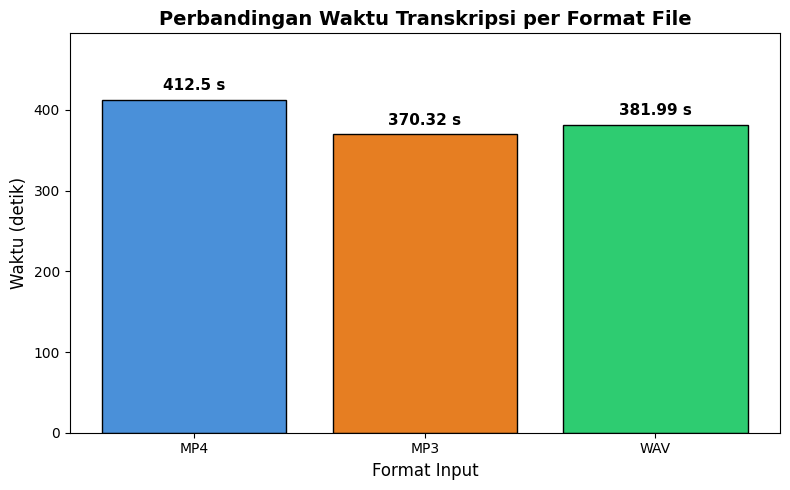

Grafik visualisasi waktu berhasil disimpan!


In [6]:
plt.figure(figsize=(8, 5))

bars = plt.bar(
    df_waktu['Format'],
    df_waktu['Waktu (detik)'],
    color=['#4A90D9', '#E67E22', '#2ECC71'],
    edgecolor='black' 
)

plt.title('Perbandingan Waktu Transkripsi per Format File', fontsize=14, fontweight='bold')
plt.ylabel('Waktu (detik)', fontsize=12)
plt.xlabel('Format Input', fontsize=12)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + (yval * 0.02), f'{yval} s', 
             ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.ylim(0, df_waktu['Waktu (detik)'].max() * 1.2)

plt.tight_layout()
plt.savefig('../dataset/perbandingan_waktu.png', dpi=150, bbox_inches='tight')
plt.show()

print("Grafik visualisasi waktu berhasil disimpan!")